In [1]:
!pip install numpy pandas scikit-learn tensorflow seaborn

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

In [3]:
# ── 1. Class names ──
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

# ── 2. Load dataset ──
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 1s 0us/step


In [4]:
# ── 3. Save labels before one-hot encoding ──
y_train_labels = y_train.copy()
y_test_labels  = y_test.copy()

# ── 4. Normalize (0-255 → 0-1) ──
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# ── 5. Reshape for CNN ──
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# ── 6. One-hot encode labels ──
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)


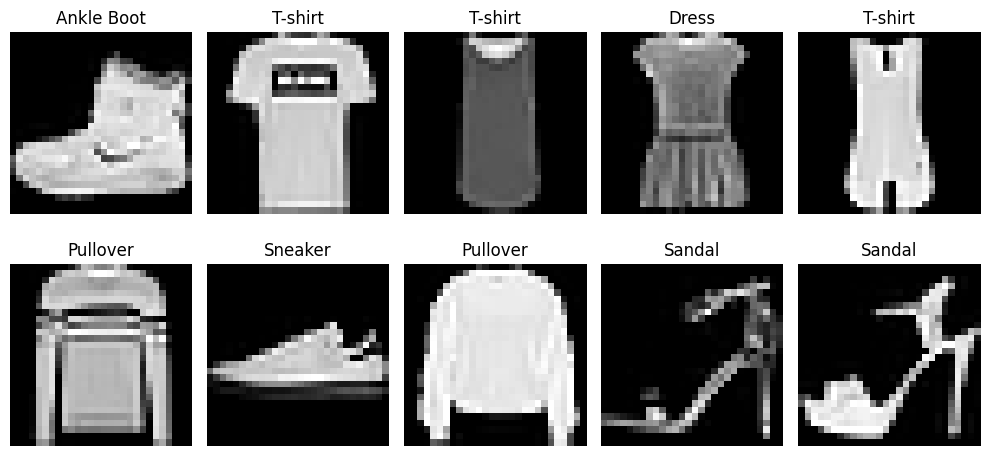

In [5]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train_labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [6]:
# ── 8. Build model ──
model = Sequential([
    Input(shape=(28, 28, 1)),   # ✅ correct way

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 128)               2

In [7]:
# ── 9. Compile ──

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ── 10. Train ──
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=128,
                    validation_data=(X_test, y_test))

Epoch 1/5
469/469 [==============================] - 35s 73ms/step - loss: 0.6444 - accuracy: 0.7654 - val_loss: 0.4279 - val_accuracy: 0.8361
Epoch 2/5
469/469 [==============================] - 32s 69ms/step - loss: 0.4147 - accuracy: 0.8537 - val_loss: 0.3476 - val_accuracy: 0.8729
Epoch 3/5
469/469 [==============================] - 31s 66ms/step - loss: 0.3639 - accuracy: 0.8691 - val_loss: 0.3289 - val_accuracy: 0.8806
Epoch 4/5
469/469 [==============================] - 38s 80ms/step - loss: 0.3293 - accuracy: 0.8801 - val_loss: 0.3032 - val_accuracy: 0.8879
Epoch 5/5
469/469 [==============================] - 35s 74ms/step - loss: 0.3061 - accuracy: 0.8893 - val_loss: 0.2851 - val_accuracy: 0.8959


313/313 [==============================] - 3s 9ms/step - loss: 0.2851 - accuracy: 0.8959
Test Accuracy: 0.8959
313/313 [==============================] - 4s 10ms/step


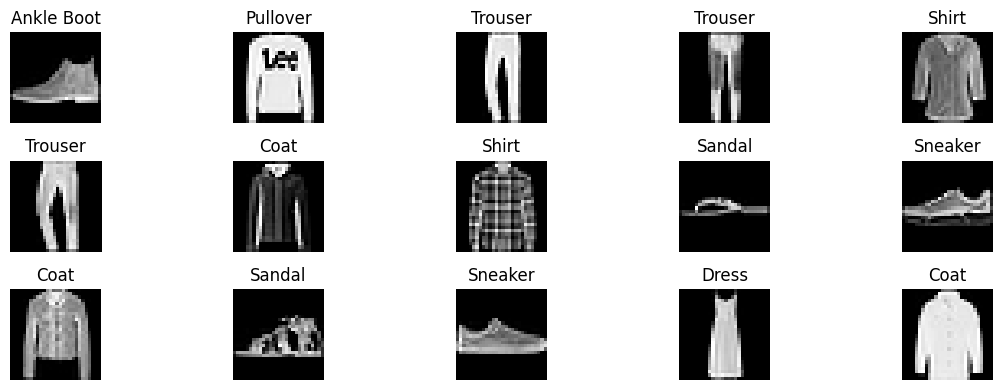

In [8]:
# ── 11. Evaluate ──
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# ── 12. Predict and show results ──
predictions = model.predict(X_test)

plt.figure(figsize=(12, 4))

for i in range(15):  
    plt.subplot(3, 5, i + 1)   
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[np.argmax(predictions[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Inspecting the notebook content to explain each line accurately.

# Read [](file:///c%3A/Users/ADMIN/OneDrive/Desktop/dl/DL_fassion.ipynb)

# ## Detailed Line-by-Line Explanation for DL_fassion.ipynb

# ### Cell 1
# - `!pip install numpy pandas scikit-learn tensorflow seaborn`  
#   Runs a shell command in the notebook to install required Python packages:
#   - `numpy` for numerical arrays,
#   - `pandas` for data handling,
#   - `scikit-learn` for preprocessing and metrics,
#   - `tensorflow` for building the CNN,
#   - `seaborn` for plotting support (though not used later).

# ---

# ### Cell 2
# - `import numpy as np`  
#   Imports NumPy and aliases it as `np` for array operations.

# - `import tensorflow as tf`  
#   Imports TensorFlow and aliases it as `tf`, which also gives access to Keras API.

# - `import matplotlib.pyplot as plt`  
#   Imports Matplotlib plotting functions as `plt`.

# - `from tensorflow.keras.models import Sequential`  
#   Imports the `Sequential` model container, useful for building a linear stack of layers.

# - `from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input`  
#   Imports layer types:
#   - `Conv2D`: 2D convolutional layer for image feature extraction,
#   - `MaxPooling2D`: spatial downsampling layer,
#   - `Flatten`: converts 2D feature maps to 1D vectors,
#   - `Dense`: fully connected layer,
#   - `Dropout`: regularization layer,
#   - `Input`: explicit input layer shape.

# - `from tensorflow.keras.utils import to_categorical`  
#   Imports utility to convert integer labels into one-hot encoded vectors.

# ---

# ### Cell 3
# - `class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']`  
#   Defines the human-readable names for the 10 Fashion MNIST classes.

# - `(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()`  
#   Loads the Fashion MNIST dataset from TensorFlow:
#   - `X_train`, `X_test`: image arrays,
#   - `y_train`, `y_test`: integer class labels.
#   The data is automatically split into training and test sets.

# ---

# ### Cell 4
# - `y_train_labels = y_train.copy()`  
#   Saves a copy of training labels before converting them to one-hot vectors, so the original label integers are still available for display.

# - `y_test_labels  = y_test.copy()`  
#   Saves a copy of test labels for the same reason.

# - `X_train = X_train / 255.0`  
#   Normalizes training images by scaling pixel values from `[0, 255]` to `[0.0, 1.0]`.

# - `X_test  = X_test  / 255.0`  
#   Normalizes test images the same way.

# - `X_train = X_train.reshape(-1, 28, 28, 1)`  
#   Reshapes training images to add the channel dimension:
#   - `-1` means infer the number of samples,
#   - `28, 28` is image height and width,
#   - `1` means grayscale channel.

# - `X_test  = X_test.reshape(-1, 28, 28, 1)`  
#   Reshapes test images identically.

# - `y_train = to_categorical(y_train, 10)`  
#   Converts training labels into one-hot encoded vectors of length 10, which is required for categorical classification.

# - `y_test  = to_categorical(y_test,  10)`  
#   Converts test labels into one-hot vectors.

# ---

# ### Cell 5
# - `plt.figure(figsize=(10, 5))`  
#   Creates a new figure with width 10 and height 5 inches.

# - `for i in range(10):`  
#   Starts a loop to display the first 10 training images.

# - `plt.subplot(2, 5, i + 1)`  
#   Creates a 2x5 grid of subplots and selects the `i+1`th subplot.

# - `plt.imshow(X_train[i].reshape(28, 28), cmap='gray')`  
#   Displays the `i`th training image in grayscale. `reshape(28, 28)` removes the channel dimension for plotting.

# - `plt.title(class_names[y_train_labels[i]])`  
#   Sets the title of the subplot to the human-readable class name corresponding to the original label.

# - `plt.axis('off')`  
#   Turns off axis ticks and labels for a cleaner image display.

# - `plt.tight_layout()`  
#   Adjusts spacing so subplots fit without overlap.

# - `plt.show()`  
#   Renders the figure.

# ---

# ### Cell 6
# - `model = Sequential([`  
#   Begins defining a sequential neural network model.

# - `Input(shape=(28, 28, 1)),   # ✅ correct way`  
#   Defines the input shape as 28x28 grayscale images with one channel.

# - `Conv2D(32, (3,3), activation='relu'),`  
#   Adds a convolutional layer with 32 filters of size 3x3 and ReLU activation. This extracts local patterns from the image.

# - `MaxPooling2D((2,2)),`  
#   Adds max pooling to downsample feature maps by a factor of 2, reducing spatial size.

# - `Conv2D(64, (3,3), activation='relu'),`  
#   Adds a second convolutional layer with 64 filters, capturing more complex features.

# - `MaxPooling2D((2,2)),`  
#   Adds another pooling layer to further reduce spatial dimensions.

# - `Flatten(),`  
#   Converts the 2D feature maps into a 1D vector so it can connect to dense layers.

# - `Dense(128, activation='relu'),`  
#   Adds a fully connected layer with 128 neurons and ReLU activation.

# - `Dropout(0.5),`  
#   Applies dropout with rate 0.5, which randomly disables half of the neurons during training to reduce overfitting.

# - `Dense(10, activation='softmax')`  
#   Adds the output layer with 10 neurons and softmax activation to produce class probabilities.

# - `])`  
#   Closes the model definition.

# - `model.summary()`  
#   Prints a summary of the model architecture, including layer shapes and number of parameters.

# ---

# ### Cell 7
# - `model.compile(optimizer='adam',`  
#   Configures the model optimizer as Adam, a common adaptive optimizer.

# - `loss='categorical_crossentropy',`  
#   Sets the loss function to categorical crossentropy, appropriate for multi-class classification with one-hot labels.

# - `metrics=['accuracy'])`  
#   Specifies accuracy as a metric to monitor during training.

# - `history = model.fit(X_train, y_train,`  
#   Starts training the model and stores the training history.

# - `epochs=5,`  
#   Trains for 5 complete passes through the training dataset.

# - `batch_size=128,`  
#   Uses mini-batches of 128 samples for each gradient update.

# - `validation_data=(X_test, y_test))`  
#   Evaluates validation loss and accuracy on the test set after each epoch.

# ---

# ### Cell 8
# - `test_loss, test_acc = model.evaluate(X_test, y_test)`  
#   Evaluates the trained model on the test data and returns loss and accuracy.

# - `print(f"Test Accuracy: {test_acc:.4f}")`  
#   Prints the test accuracy formatted to four decimal places.

# - `predictions = model.predict(X_test)`  
#   Generates predicted probability distributions for each test image.

# - `plt.figure(figsize=(12, 4))`  
#   Creates a new figure sized 12x4 inches.

# - `for i in range(15):`  
#   Loops over the first 15 test samples to display predictions.

# - `plt.subplot(3, 5, i + 1)`  
#   Creates a 3x5 grid of subplots and selects the appropriate one.

# - `plt.imshow(X_test[i].reshape(28, 28), cmap='gray')`  
#   Displays the `i`th test image.

# - `plt.title(class_names[np.argmax(predictions[i])])`  
#   Sets the title to the predicted class name by taking the index with the highest predicted probability.

# - `plt.axis('off')`  
#   Hides axis details.

# - `plt.tight_layout()`  
#   Adjusts subplot spacing.

# - `plt.show()`  
#   Displays the prediction visualization.

# ---

# ### Cell 9
# - Empty cell with no code.

# If you want, I can also summarize what each major block of this notebook does in one sentence each.

In [ ]:
# ## Expected Viva Questions with Answers for DL_fassion.ipynb

# ### Dataset and preprocessing
# 1. **What dataset is used in this notebook?**  
#    - The Fashion MNIST dataset, loaded from `tf.keras.datasets.fashion_mnist`.

# 2. **What are the class labels in this dataset?**  
#    - Ten classes: `T-shirt`, `Trouser`, `Pullover`, `Dress`, `Coat`, `Sandal`, `Shirt`, `Sneaker`, `Bag`, and `Ankle Boot`.

# 3. **Why do we normalize images with `X_train / 255.0`?**  
#    - To scale pixel values from `0-255` to `0-1`, which improves neural network training stability and speed.

# 4. **Why reshape `X_train` and `X_test` to `(28, 28, 1)`?**  
#    - Because convolutional layers expect a channel dimension, and Fashion MNIST images are grayscale.

# 5. **Why do we save `y_train_labels` before one-hot encoding?**  
#    - To keep the original integer labels for plotting or interpreting class names later.

# ---

# ### Model architecture
# 6. **Why use a `Sequential` model?**  
#    - Because the network is a simple linear stack of layers with no branching.

# 7. **What does `Input(shape=(28, 28, 1))` specify?**  
#    - It defines the expected input shape: 28x28 pixels with one color channel.

# 8. **What does `Conv2D(32, (3,3), activation='relu')` do?**  
#    - It applies 32 convolution filters of size 3x3 and uses ReLU activation to learn image features.

# 9. **Why add `MaxPooling2D((2,2))` after convolution?**  
#    - To downsample feature maps and reduce spatial dimensions while keeping strong features.

# 10. **Why is there a second `Conv2D` layer with 64 filters?**  
#     - To learn more complex, higher-level features after the first convolution and pooling.

# 11. **What does `Flatten()` do?**  
#     - It converts 2D feature maps into a 1D vector for the dense classification layers.

# 12. **Why use `Dense(128, activation='relu')`?**  
#     - To learn nonlinear combinations of extracted features before final classification.

# 13. **What is the role of `Dropout(0.5)`?**  
#     - It randomly drops half of the neurons during training to reduce overfitting.

# 14. **Why does the final layer use `Dense(10, activation='softmax')`?**  
#     - Because there are 10 classes and softmax outputs class probabilities.

# ---

# ### Training
# 15. **Why is `optimizer='adam'` chosen?**  
#     - Adam adapts learning rates automatically and generally works well for CNN training.

# 16. **Why is `loss='categorical_crossentropy'` used?**  
#     - It is the standard loss for multi-class classification with one-hot encoded labels.

# 17. **What does `metrics=['accuracy']` measure?**  
#     - It measures the proportion of correctly classified images.

# 18. **What do `epochs=5` and `batch_size=128` mean?**  
#     - The model trains for 5 full passes over the training data, updating weights in batches of 128 samples.

# 19. **What is stored in `history`?**  
#     - Training and validation loss and accuracy recorded after each epoch.

# ---

# ### Evaluation and prediction
# 20. **What does `model.evaluate(X_test, y_test)` do?**  
#     - It computes the model’s loss and accuracy on unseen test data.

# 21. **Why call `model.predict(X_test)` after evaluation?**  
#     - To obtain predicted probabilities for each test image and visualize the model’s predictions.

# 22. **How do we get the predicted class label from probabilities?**  
#     - By using `np.argmax(predictions[i])` to select the highest probability class.

# 23. **Why plot test images with predicted labels?**  
#     - To visually inspect whether the model’s predicted classes match the images.

# 24. **What would a perfect model plot look like?**  
#     - Every displayed image title would match the true class of the image.

# ---

# ### Theory and improvement
# 25. **Why is CNN a good choice for Fashion MNIST?**  
#     - Because CNNs can learn spatial patterns in images, making them ideal for image classification.

# 26. **What is overfitting and how does this model try to prevent it?**  
#     - Overfitting is memorizing training data instead of generalizing. Dropout helps reduce it.

# 27. **Why are validation metrics useful during training?**  
#     - They show how well the model performs on unseen data and help detect overfitting.

# 28. **How could this model be improved further?**  
#     - Use more epochs, data augmentation, larger networks, or regularization techniques.

# 29. **Why is one-hot encoding needed for categorical labels?**  
#     - Because categorical crossentropy expects labels in a binary vector format for each class.

# 30. **What does the `softmax` activation function do in the output layer?**  
#     - It converts raw scores into probabilities that sum to 1 across all classes.

# If you want, I can also provide a shorter set of 10 rapid-fire questions with answers.